<a href="https://colab.research.google.com/github/tristansalazar/MachineLearning-/blob/main/Unidad2/Practica6_U2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from IPython.display import Markdown, display

display(Markdown("""
# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 6:** XGBoost_Regresion

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## XGBoost (Extreme Gradient Boosting)

**Cómo funciona**
- Algoritmo **basado en árboles** que utiliza boosting: **construye árboles secuenciales donde cada uno corrige los errores del anterior**. Optimiza mediante gradiente y regularización.
- Es un algoritmo de ensamble basado en árboles que utiliza boosting para combinar múltiples modelos débiles.

**Ventajas**
- Alta precisión y velocidad.
- Capacidad de manejar valores faltantes automáticamente.
- Control del sobreajuste mediante regularización.
- Soporta paralelización.

**Limitaciones**
- Más complejo de configurar (muchos parámetros).
- Puede ser costoso computacionalmente.

**Comparación con los modelos anteriores**

| Modelo | Linealidad | Flexibilidad | Overfitting | Escalable | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Media |
| Random Forest | Baja | Alta | Baja | Alta | Baja |
| SVR | Muy Baja | Alta | Baja | Baja | Baja |
| XGBoost | Baja | Muy Alta | Baja | Alta | Media |
"""))


# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 6:** XGBoost_Regresion

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## XGBoost (Extreme Gradient Boosting)

**Cómo funciona**
- Algoritmo **basado en árboles** que utiliza boosting: **construye árboles secuenciales donde cada uno corrige los errores del anterior**. Optimiza mediante gradiente y regularización.
- Es un algoritmo de ensamble basado en árboles que utiliza boosting para combinar múltiples modelos débiles.

**Ventajas**
- Alta precisión y velocidad.
- Capacidad de manejar valores faltantes automáticamente.
- Control del sobreajuste mediante regularización.
- Soporta paralelización.

**Limitaciones**
- Más complejo de configurar (muchos parámetros).
- Puede ser costoso computacionalmente.

**Comparación con los modelos anteriores**

| Modelo | Linealidad | Flexibilidad | Overfitting | Escalable | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Media |
| Random Forest | Baja | Alta | Baja | Alta | Baja |
| SVR | Muy Baja | Alta | Baja | Baja | Baja |
| XGBoost | Baja | Muy Alta | Baja | Alta | Media |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [3]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 10882624.65
Coeficiente de determinación (R²): 0.91


In [7]:
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 3298.88


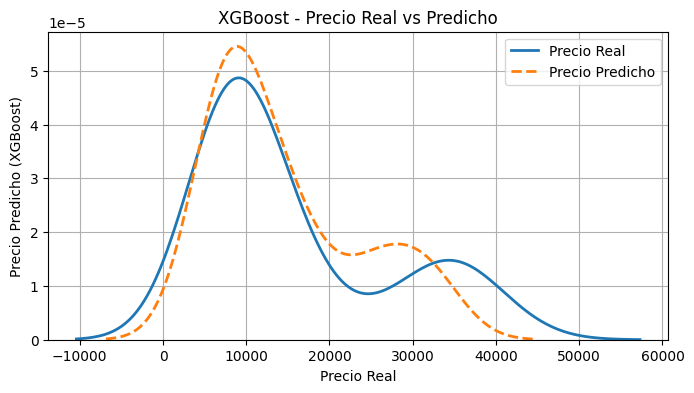

In [8]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

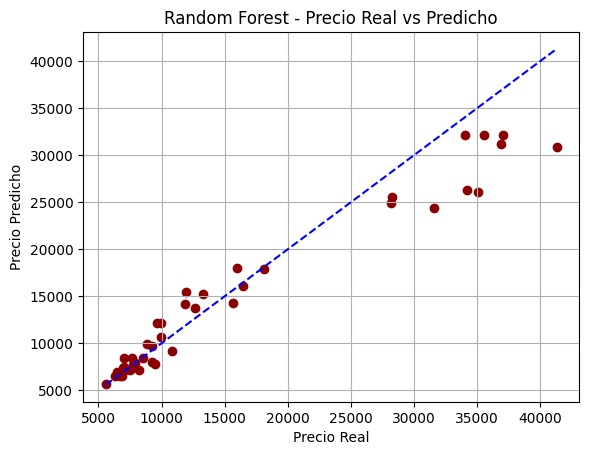

In [9]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

Error cuadrático medio (MSE): 9242721.95
Coeficiente de determinación (R²): 0.92
Raíz del Error cuadrático medio (RMSE): 3040.18




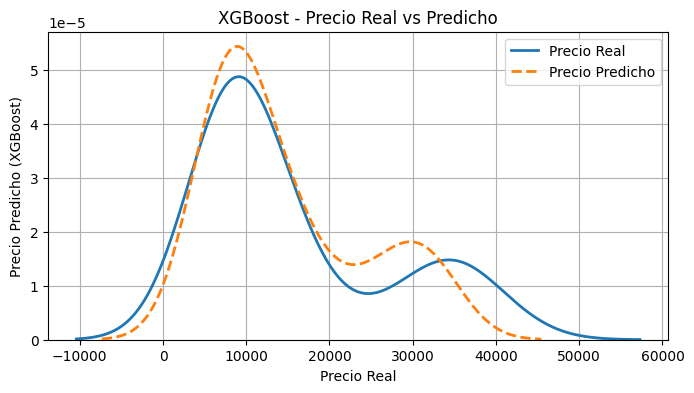

In [10]:
xgb_model2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model2.fit(X_train, y_train)

y_pred = xgb_model2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

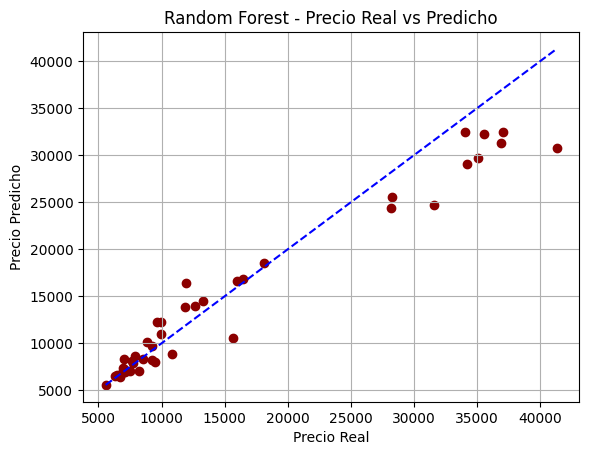

In [11]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV

xgb_base = XGBRegressor(random_state=42, eval_metric='rmse')

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

print("Mejores Parámetros:", grid_search_xgb.best_params_)
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores Parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7}


Error cuadrático medio (MSE): 14396198.08
Coeficiente de determinación (R²): 0.88
Raíz del Error cuadrático medio (RMSE): 3794.23




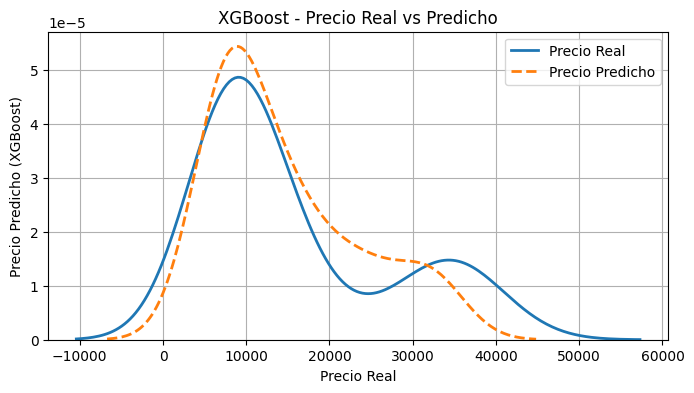

In [13]:
best_xgb_model = XGBRegressor(
    colsample_bytree=0.7,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    n_estimators=300,
    subsample=0.9,
    random_state=42,
    eval_metric='rmse'
)

best_xgb_model.fit(X_train, y_train)

y_pred = best_xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

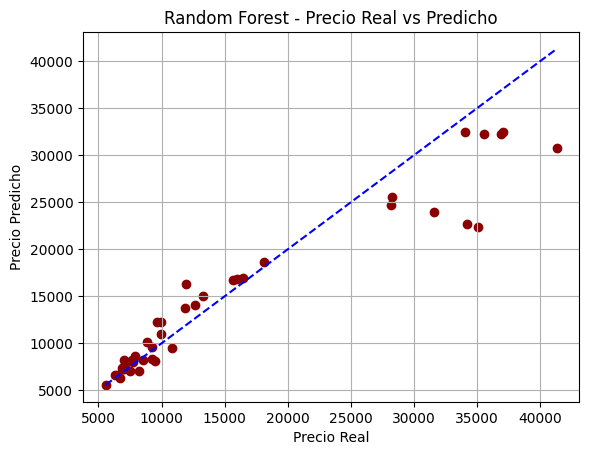

In [14]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()